In [92]:
import math
import matplotlib.pyplot as plt
import numpy as np

In [93]:
def get_mean_variance(v):
    '''
    given a vector of observations, returns the mean and variance of the estimator estimating the object whose observations are in v
    Args:
        v (np.ndarray[np.float64]): list of observations
    Returns:
        float, float (mean and variance of the estimator)
    '''
    vmean = np.mean(v)
    vvar = 0
    lv = len(v)
    for i in range(lv):
        vvar += (v[i]-vmean)**2
    vvar /= (lv*(lv-1))
    return vmean, vvar

### Q5

In [94]:
def f(z):
    return z**3*math.exp(z)

In [95]:
def generate_gaussian(mu, sigma):
    '''
    Generate the realization of a gaussian random variable with mean mu and variance sigma**2 using box muller method
    Args:
        mu (float): mean
        sigma (float): standard deviation
    Returns:
        2 iid realizations of N(mu, sigma**2) (float, float)    
    '''
    u1, u2 = np.random.rand(), np.random.rand()
    v1 = 2*u1 - 1
    v2 = 2*u2 - 1
    while(v1**2 + v2**2 > 1):
        u1 = np.random.rand()
        u2 = np.random.rand()
        v1, v2 = 2*u1 - 1, 2*u2 - 1
    r2 = v1**2 + v2**2
    x = math.sqrt(-2*math.log(r2)/r2)*v1
    x = x*sigma+mu
    y = math.sqrt(-2*math.log(r2)/r2)*v2
    y = y*sigma+mu
    return x, y

#### (a)

In [98]:
valvec = []
m = 5000000
for i in range(m):
    if(i%2 == 0):
        g1, g2 = generate_gaussian(0, 1) # 2 independent realizations => can be used for 2 distinct rounds
    if(i%2 == 0):
        z1 = g1
    else:
        z1 = g2
    z2 = -z1
    valvec.append((f(z1)+f(z2))/2)
valvec = np.array(valvec)
mean1, var1 = get_mean_variance(valvec)
print(mean1, var1)

6.592258550618809 0.0004398794982798937


#### (b)

In [99]:
print("95% CI:")
print(mean1 - 1.96*math.sqrt(var1), mean1 + 1.96*math.sqrt(var1))

95% CI:
6.551150873956268 6.633366227281351


### Q10

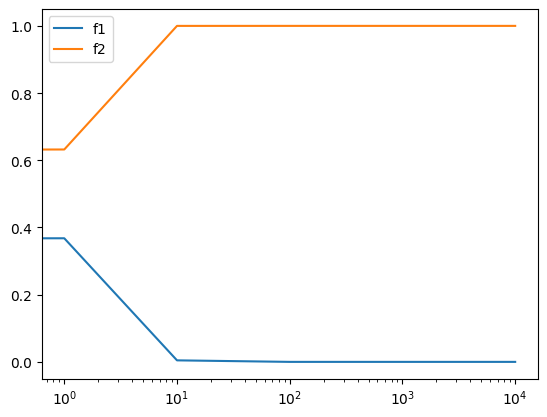

In [21]:
def f1(a):
    return a**2*math.exp(-a)
def f2(a):
    return 1-math.exp(-a)

avec = [0]+[10**i for i in range(5)]
f1vec = []
f2vec = []
for a in avec:
    f1vec.append(f1(a))
    f2vec.append(f2(a))
plt.plot(avec, f1vec, label="f1")
plt.plot(avec, f2vec, label="f2")
plt.legend()
plt.xscale("log")
plt.show()

### Q12

#### (b)

In [87]:
num_iters = 100
u_vec, py_vec, p_vec, y_vec, y2_vec = [], [], [], [], []
for i in range(num_iters):
    u = np.random.rand()
    u_vec.append(u)
    p = math.exp(u**2)
    p_vec.append(p)
    y = u
    y_vec.append(y)
    y2_vec.append(y**2)
    py_vec.append(p*y)
u_vec, py_vec, p_vec, y_vec, y2_vec = np.array(u_vec), np.array(py_vec), np.array(p_vec), np.array(y_vec), np.array(y2_vec)
Epy = np.mean(py_vec)
Ep = np.mean(p_vec)
Ey = np.mean(y_vec)
Ey2 = np.mean(y2_vec)
covpy = Epy - Ep*Ey
vary = Ey2 - Ey**2
c = -covpy/vary
print("c*:", c)

c*: -1.6395917330211713


In [88]:
val_control_estimator_vec = []
for i in range(num_iters):
    val_control_estimator_vec.append(p_vec[i] + c*(y_vec[i]-1/2)) # 1/2 = E(y) = E(u) = E(U[0, 1]) which we already know!
vce_mean, vce_var = get_mean_variance(val_control_estimator_vec)
print("control estimator variance:", vce_var)

control estimator variance: 0.0002682809858749703


#### (c)

In [89]:
val_antithetic_estimator_vec = []
for i in range(num_iters):
    v1 = math.exp(u_vec[i]**2)
    v2 = math.exp((1-u_vec[i])**2)
    val_antithetic_estimator_vec.append((v1+v2)/2)
vae_mean, vae_var = get_mean_variance(val_antithetic_estimator_vec)
print("antithetic estimator variance:", vae_var)

antithetic estimator variance: 0.00024951748874321836


#### (d)

##### As seen, both perform almost equally well but Antithetic estimator wins the race (has lower variance) with a narrow margin!